# EDA & ML Regresión Logística

Cómo funciona la R.Lineal / R. Logística
| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |

# Paso 0: **Imports**


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Escalado
from sklearn.preprocessing import StandardScaler

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas de regresión
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# **EDA**

## Paso 1: **Data & Problem Description**

In [2]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv", sep=',')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


###  **Problem desciption**

* **Objetivo:** Predecir el coste del seguro médico de una persona en función de variables como; edad, BMI, número de hijos, si fuma, región, sexo...


* **Planteamiento:** Esto es un problema de regresión supervisada, porque el objetivo es predecir un valor numérico continuo. La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, **cuál va a ser la prima (coste) que debe asumir cada uno de ellos**. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

###  **Data Variables**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 1338 filas y 7 columnas  
> * Los datos que aporta el datset son 4 columnas de tipo numérico (enteros y decimales) y 3 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(2), int64(2), object(3)``  
>  
> | variable | tipo              |  
> | -------- | ----------------- |  
> | age      | numérica          |  
> | sex      | categórica        |  
> | bmi      | numérica          |  
> | children | numérica          |  
> | smoker   | categórica        |  
> | region   | categórica        |  
> | charges  | numérica (target) |  
>  
> 1. ``age``. Edad del beneficiario principal (numérico)
> 2. ``sex``. Género del beneficiario principal (categórico)
> 3. ``bmi``. índice de masa corporal (numérico)
> 4. ``children``. Número de niños/dependientes cubiertos por un seguro médico (numérico)
> 5. ``smoker``. ¿Es fumador? (categórico)
> 6. ``region``. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
> 7. ``charges``. Prima del seguro médico (numérico)


## Paso 2: **Limpieza de datos**

### **Duplicados y valores nulos**

In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.isna().sum() # Compruebo si hay datos nulos (datos faltantes)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df_dupl = df[df.duplicated(subset=df.columns, keep=False)]
df_dupl # Print df de las columnas duplicadas para ver la fila duplicada

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df = df.drop_duplicates()

> **Conclusión de la limpieza de datos:** Las columnas no contienen valores nulos y hay solamente una fila duplicada.

## Paso 3: **Análisis de las variables:**

### **Variable target** 
> * ``charges``, variable target escogida ya que nos indica el valor prima del seguro médico que ya tenía cada persona.

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [9]:
df['charges'].max()

np.float64(63770.42801)

In [10]:
df[df['charges']>30000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1308,25,female,30.200,0,yes,southwest,33900.65300
1313,19,female,34.700,2,yes,southwest,36397.57600


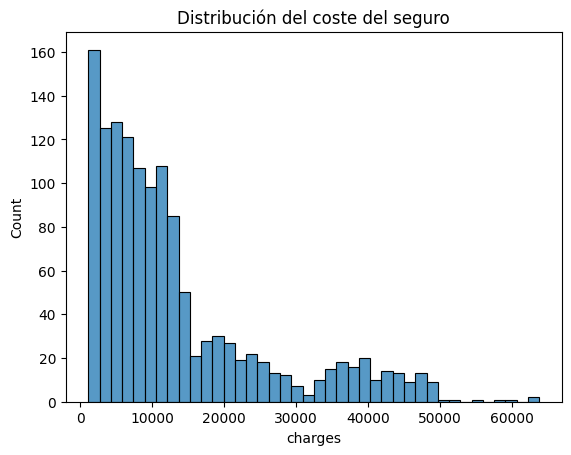

In [11]:
sns.histplot(df["charges"], bins=40)

plt.title("Distribución del coste del seguro")

plt.show()

### **Columna vs Target**

* **Edad**

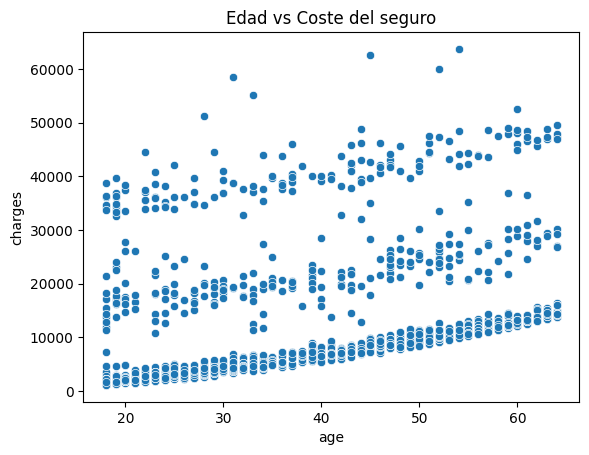

In [12]:
sns.scatterplot(data=df, x="age", y="charges")

plt.title("Edad vs Coste del seguro")

plt.show()

* **Fumador**

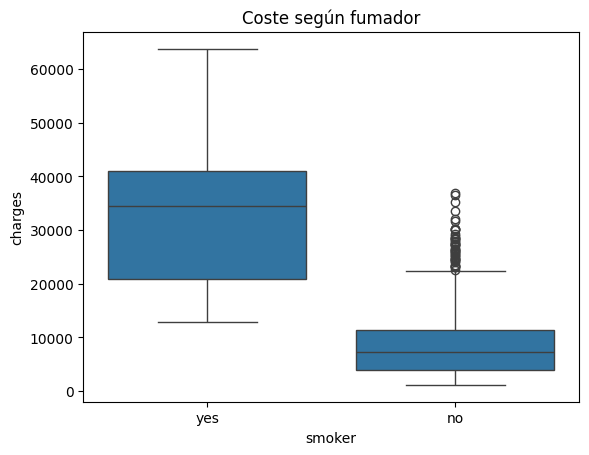

In [13]:
sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Coste según fumador")

plt.show()

> **Observaciones:**  
> La distribución suele ser asimétrica, con muchos valores altos asociados a fumadores.  
> La edad del cliente también sesga los picos del gráfico ya que como de observa en 'Edad vs Coste del seguro' los mayores de 60 años pagan mínimo 10.000 $.

### **Normalizado de datos categóricos**

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### **Correlaciones**

* **Factorización**

In [15]:
df_factorize = df.copy()

In [16]:
df_factorize['smoker_y'] = pd.factorize(df['smoker'])[0]
df_factorize['region_y'] = pd.factorize(df['region'])[0]
df_factorize['sex_y'] = pd.factorize(df['sex'])[0]

In [17]:
# No recuerdo que hacia include=['number']
df_numerico = df_factorize.select_dtypes(include=['number'])

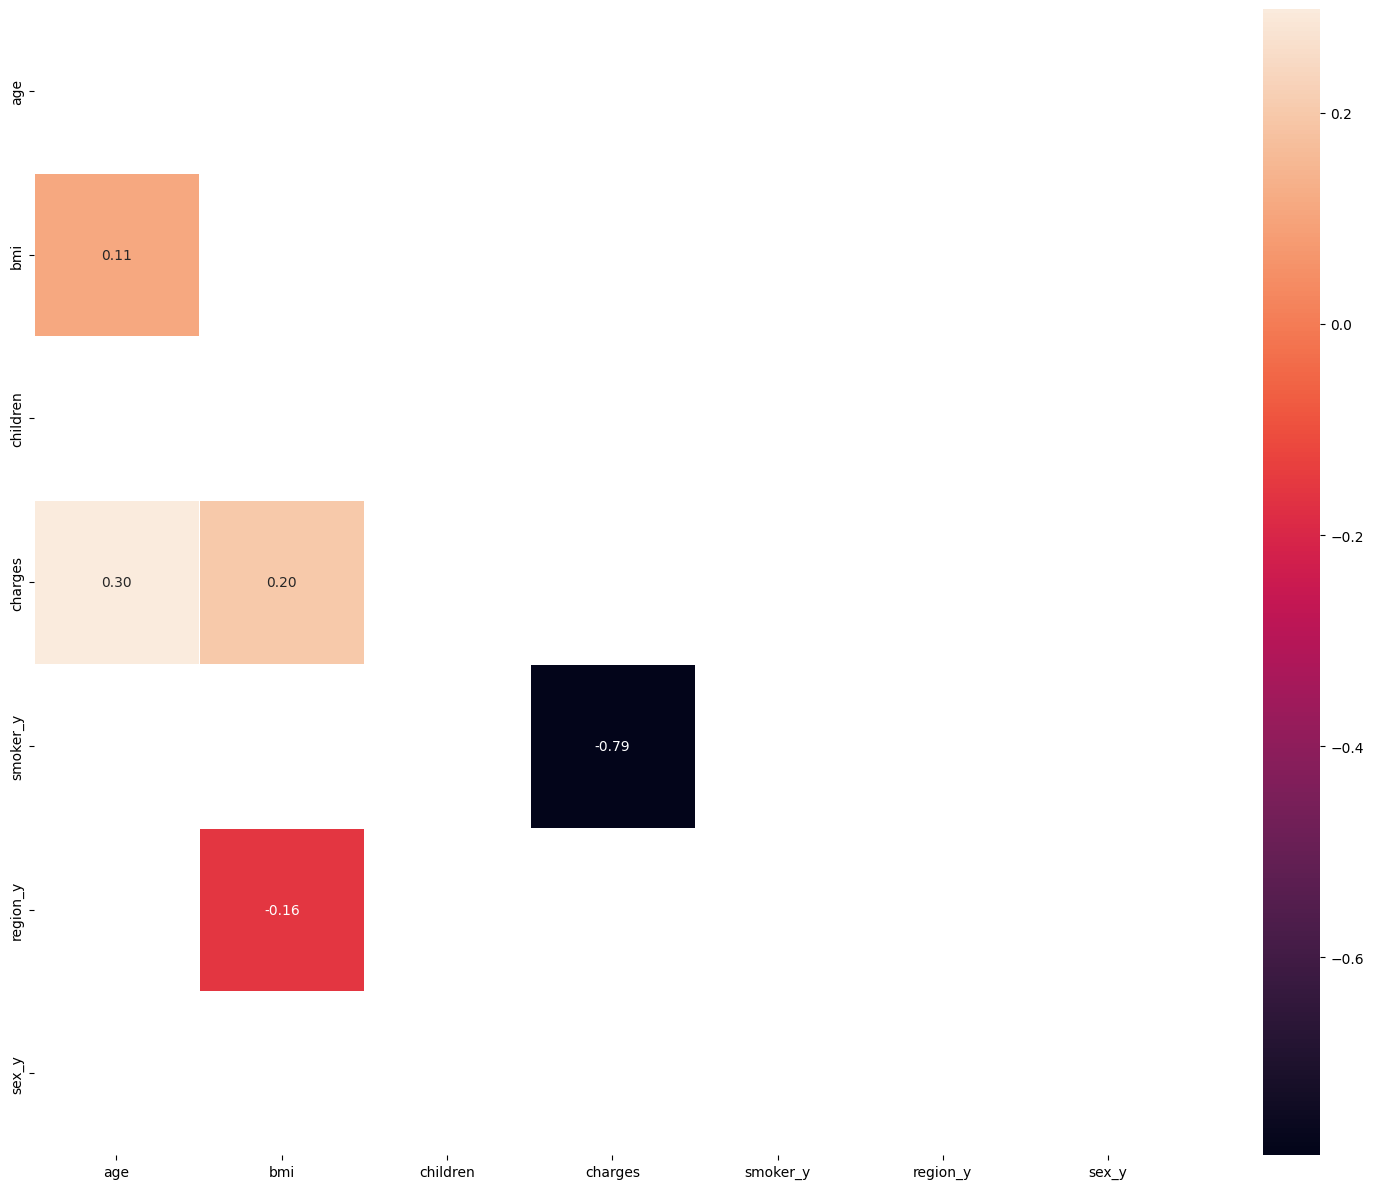

In [18]:
corr = df_numerico.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Conclusiones:**
Eliminar columnas x - Después hacer OTRO HEATMAP PARA VER NUEVAS CORRELACIONES

# **ML**

## Paso 1: **Split Data: train & test**

In [19]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

## Paso 2: **Escalado de datos**

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Paso 3: **Modelo inical: Linear Regression**

In [22]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Predicción del modelo**

In [23]:
y_pred = model.predict(X_test_scaled)
y_pred[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

## Paso 4: **Métricas**

### 1. **MAE (Mean Absolute Error)**

> Indica el error medio en dólares.

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mae

4177.045561036324

### 2. **MSE**

> Penaliza más errores grandes.

In [25]:
mse = mean_squared_error(y_test, y_pred)
mse

35478020.67523561

### 3. **R² Score**

> Indica qué porcentaje de la variabilidad explica el modelo.

In [26]:
r2 = r2_score(y_test, y_pred)
r2

0.8069287081198011

> **Observación:** El modelo explica 78% de la variabilidad de los costes.

## Paso 5: **Comparación con otros modelos de regresión**

### **Desicion Tree Regressor**

In [27]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_scaled, y_train)
pred_tree = tree.predict(X_test_scaled)
print("R2 Tree:", r2_score(y_test, pred_tree))

R2 Tree: 0.8097857115858496


### **Random Forest Regressor**

In [28]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("R2 Random Forest:", r2_score(y_test, pred_rf))

R2 Random Forest: 0.8782485052664795


### **Comparación de modelos**

In [29]:
results = {"Linear Regression": r2_score(y_test, y_pred),"Decision Tree": r2_score(y_test, pred_tree),"Random Forest": r2_score(y_test, pred_rf)}
results

{'Linear Regression': 0.8069287081198011,
 'Decision Tree': 0.8097857115858496,
 'Random Forest': 0.8782485052664795}

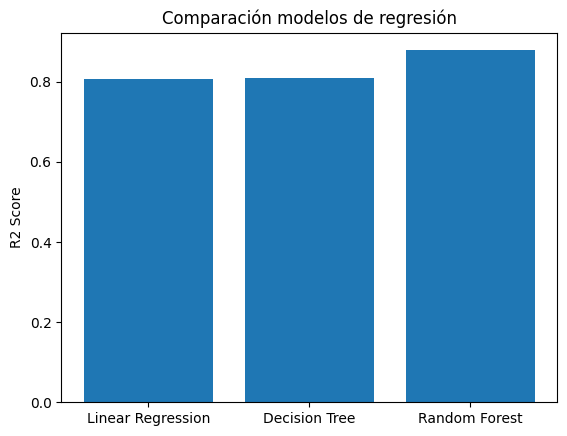

In [30]:
plt.bar(results.keys(), results.values())
plt.title("Comparación modelos de regresión")
plt.ylabel("R2 Score")
plt.show()

> **Se compararon distintos modelos:** Linear Regression, Decision Tree, Random Forest.  
> Los modelos basados en árboles, como Random Forest, suelen capturar mejor relaciones no lineales y pueden obtener un R² mayor.

* **Hiperparametrización de Random Forest**

In [31]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({    "feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)
importance_df

,feature,importance
4,smoker_yes,0.600777
1,bmi,0.216088
0,age,0.135726
2,children,0.022938
3,sex_male,0.007076
5,region_northwest,0.006779
6,region_southeast,0.006045
7,region_southwest,0.004570


> **Observaciones:** Las variables que más influyen en el coste del seguro suelen ser: smoker, age, bmi.

### **Guardado de data codificada**

In [32]:
with open('/workspaces/betaniammc-machine-learning/models/logistic-regression-label-encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder_contact, file)

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/betaniammc-machine-learning/models/logistic-regression-label-encoder.pkl'

### **Escalado de normalización**

In [ ]:
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

### **Generar modelo de entrenamiento de datos (con los datos ya escalados)**

In [ ]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train_cat_le_scaled, y_train)

NameError: name 'LogisticRegression' is not defined